## PRCP-1008-NBAShotSelection

### TABLE OF CONTENTS
1. Understanding the Objective
2. Importing Required Libraries
3. Loading the Dataset and EDA
4. Using Semi-Supervised Model
5. Scaling & Feature Engineering
6. Model Development
7. Conclusion and Insights

### 1. Objective:
    Building a model to predict whether the player will score or not score, based on the given features.

### 2. Importing Necessaary Libraries

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#Importing the Data Set

nba = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\DATAMITES\PROJECT\NBA\Data\data.csv")
nba

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30692,Jump Shot,Jump Shot,397,49900088,33.9963,1,48,-118.2688,6,4,...,2PT Field Goal,Center(C),In The Paint (Non-RA),Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30693
30693,Tip Shot,Tip Shot,398,49900088,34.0443,0,0,-118.2698,6,4,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30694
30694,Running Jump Shot,Jump Shot,426,49900088,33.8783,-134,166,-118.4038,3,4,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30695
30695,Jump Shot,Jump Shot,448,49900088,33.7773,31,267,-118.2388,2,4,...,3PT Field Goal,Center(C),Above the Break 3,24+ ft.,1610612747,Los Angeles Lakers,2000-06-19,LAL vs. IND,IND,30696


### 3.Exploratory Data Analysis:
Duplicate Check: Verify the dataset for any duplicate entries to prevent redundant data. If duplicates are found, they should be removed to enhance the model’s performance.

Null Value Check: Inspect the dataset for missing values to avoid bias. If null values are present, they should be appropriately imputed or replaced based on the nature of the data.

Data Type Verification: Examine the data types of all features. If any non-numerical features exist, they must be encoded into numerical format before model training.

Statistical Summary: Perform an overall statistical analysis to understand metrics such as mean, median, standard deviation, and maximum values. This helps in effective feature engineering.

Visualization: Create visualizations to analyze features and gain better insights into their relationships.

In [11]:
nba.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


In [12]:
nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [13]:
nba.columns

Index(['action_type', 'combined_shot_type', 'game_event_id', 'game_id', 'lat',
       'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs',
       'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag',
       'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range',
       'team_id', 'team_name', 'game_date', 'matchup', 'opponent', 'shot_id'],
      dtype='object')

In [14]:
nba.describe()

,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,shot_id
count,30697.000000,3.069700e+04,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,25697.000000,3.069700e+04,30697.000000
mean,249.190800,2.476407e+07,33.953192,7.110499,91.107535,-118.262690,4.885624,2.519432,0.146562,28.365085,13.437437,0.446161,1.610613e+09,15349.000000
std,150.003712,7.755175e+06,0.087791,110.124578,87.791361,0.110125,3.449897,1.153665,0.353674,17.478949,9.374189,0.497103,0.000000e+00,8861.604943
min,2.000000,2.000001e+07,33.253300,-250.000000,-44.000000,-118.519800,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.610613e+09,1.000000
25%,110.000000,2.050008e+07,33.884300,-68.000000,4.000000,-118.337800,2.000000,1.000000,0.000000,13.000000,5.000000,0.000000,1.610613e+09,7675.000000
50%,253.000000,2.090035e+07,33.970300,0.000000,74.000000,-118.269800,5.000000,3.000000,0.000000,28.000000,15.000000,0.000000,1.610613e+09,15349.000000
75%,368.000000,2.960047e+07,34.040300,95.000000,160.000000,-118.174800,8.000000,3.000000,0.000000,43.000000,21.000000,1.000000,1.610613e+09,23023.000000
max,659.000000,4.990009e+07,34.088300,248.000000,791.000000,-118.021800,11.000000,7.000000,1.000000,59.000000,79.000000,1.000000,1.610613e+09,30697.000000


In [15]:
nba.isnull().sum()

action_type              0
combined_shot_type       0
game_event_id            0
game_id                  0
lat                      0
loc_x                    0
loc_y                    0
lon                      0
minutes_remaining        0
period                   0
playoffs                 0
season                   0
seconds_remaining        0
shot_distance            0
shot_made_flag        5000
shot_type                0
shot_zone_area           0
shot_zone_basic          0
shot_zone_range          0
team_id                  0
team_name                0
game_date                0
matchup                  0
opponent                 0
shot_id                  0
dtype: int64

In [16]:
nba.duplicated().sum()

np.int64(0)

In [17]:
nba=nba.drop(["game_event_id","game_id","team_id","team_name","shot_id"], axis=1)

In [18]:
nba.head()

,action_type,combined_shot_type,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,season,seconds_remaining,shot_distance,shot_made_flag,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,game_date,matchup,opponent
0,Jump Shot,Jump Shot,33.9723,167,72,-118.1028,10,1,0,2000-01,27,18,NaN,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,2000-10-31,LAL @ POR,POR
1,Jump Shot,Jump Shot,34.0443,-157,0,-118.4268,10,1,0,2000-01,22,15,0.0,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,2000-10-31,LAL @ POR,POR
2,Jump Shot,Jump Shot,33.9093,-101,135,-118.3708,7,1,0,2000-01,45,16,1.0,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,2000-10-31,LAL @ POR,POR
3,Jump Shot,Jump Shot,33.8693,138,175,-118.1318,6,1,0,2000-01,52,22,0.0,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,2000-10-31,LAL @ POR,POR
4,Driving Dunk Shot,Dunk,34.0443,0,0,-118.2698,6,2,0,2000-01,19,0,1.0,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,2000-10-31,LAL @ POR,POR


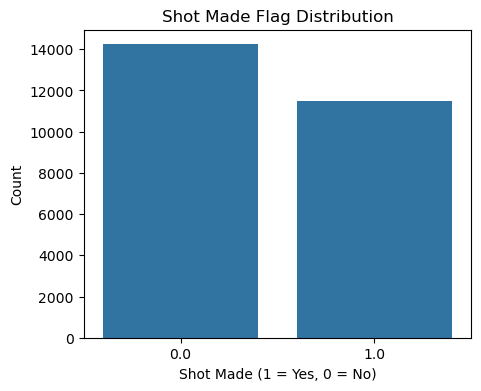

shot_made_flag
0.0    0.553839
1.0    0.446161
Name: proportion, dtype: float64


In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x='shot_made_flag', data=nba)
plt.title("Shot Made Flag Distribution")
plt.xlabel("Shot Made (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

print(nba['shot_made_flag'].value_counts(normalize=True))

- The dataset is moderately imbalanced, with more missed shots (0) than made shots (1).
- This indicates that the model must focus on correctly identifying successful shots despite the imbalance.

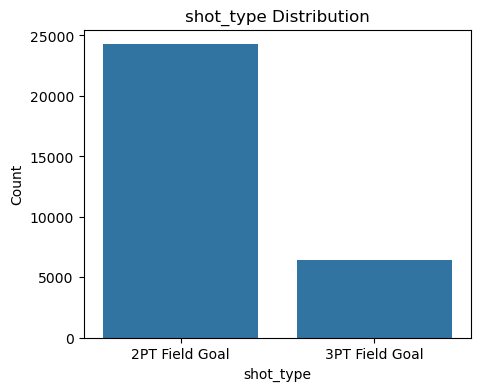

shot_type
2PT Field Goal    0.790664
3PT Field Goal    0.209336
Name: proportion, dtype: float64


In [20]:
plt.figure(figsize=(5,4))
sns.countplot(x='shot_type', data=nba)
plt.title("shot_type Distribution")
plt.xlabel("shot_type")
plt.ylabel("Count")
plt.show()

print(nba['shot_type'].value_counts(normalize=True))

- The majority of attempts are 2-point shots, with 3-pointers being fewer in comparison.
- This reflects typical NBA gameplay where players attempt more mid-range and close-range shots.

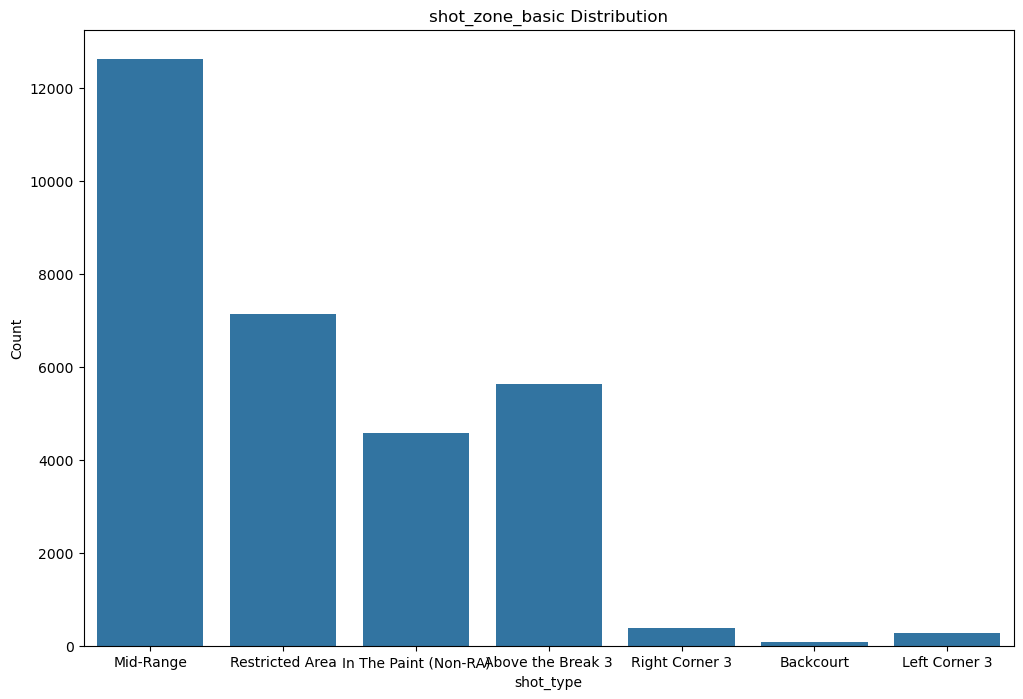

shot_zone_basic
Mid-Range                0.411278
Restricted Area          0.232466
Above the Break 3        0.183080
In The Paint (Non-RA)    0.149135
Right Corner 3           0.012607
Left Corner 3            0.009121
Backcourt                0.002313
Name: proportion, dtype: float64


In [21]:
plt.figure(figsize=(12,8))
sns.countplot(x='shot_zone_basic', data=nba)
plt.title("shot_zone_basic Distribution")
plt.xlabel("shot_type")
plt.ylabel("Count")
plt.show()

print(nba['shot_zone_basic'].value_counts(normalize=True))

- Most shots are taken from the mid-range zones and Restricted Area.
- This gives an understanding of player positioning trends on the court.

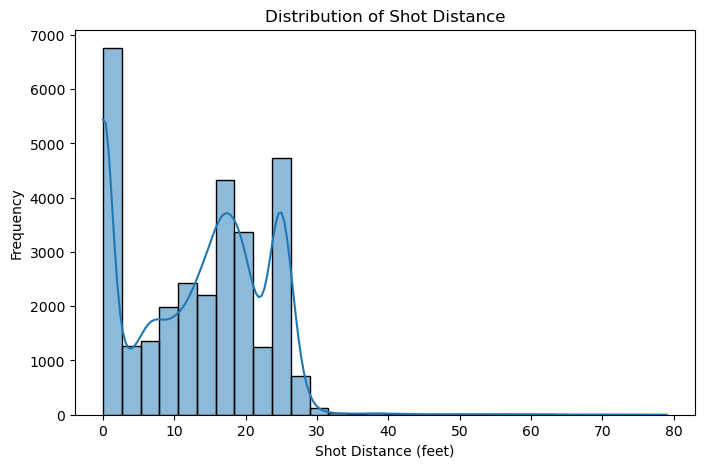

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=nba, x='shot_distance', kde=True, bins=30)
plt.title("Distribution of Shot Distance")
plt.xlabel("Shot Distance (feet)")
plt.ylabel("Frequency")
plt.show()

Shot distance is right-skewed, meaning players take more short and mid-range shots than long-distance shots.

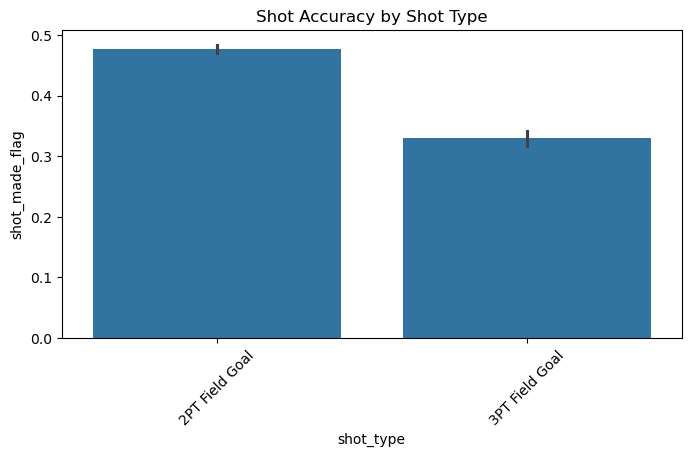

In [23]:
plt.figure(figsize=(8,4))
sns.barplot(x='shot_type', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Shot Type")
plt.xticks(rotation=45)
plt.show()

- 2-point shots have a higher conversion rate compared to 3-point shots.
- This is expected since closer shots are easier to score.

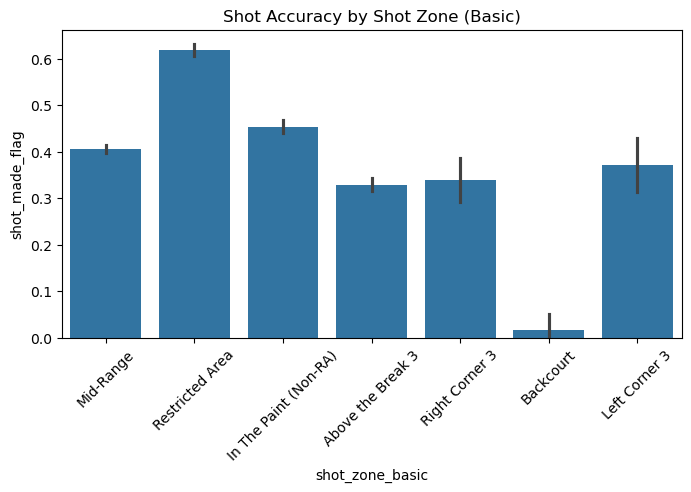

In [24]:
plt.figure(figsize=(8,4))
sns.barplot(x='shot_zone_basic', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Shot Zone (Basic)")
plt.xticks(rotation=45)
plt.show()

- Shots taken from close-range zones show higher accuracy.
- Mid-range and perimeter shots tend to have lower conversion rates.

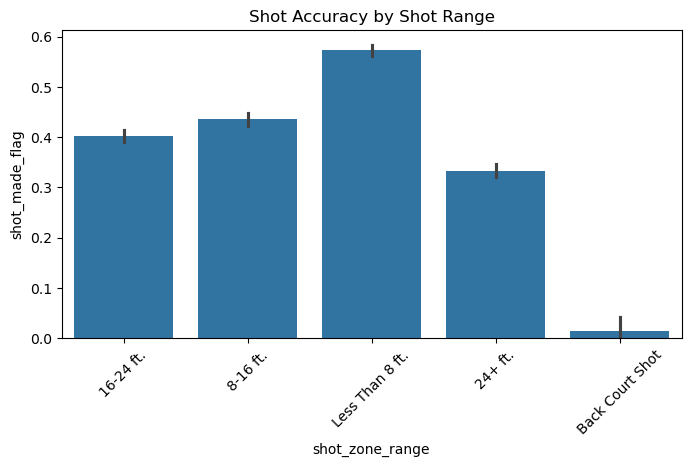

In [25]:
plt.figure(figsize=(8,4))
sns.barplot(x='shot_zone_range', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Shot Range")
plt.xticks(rotation=45)
plt.show()

As the distance increases from "Less Than 8 ft" to "24+ ft", the shot success decreases.

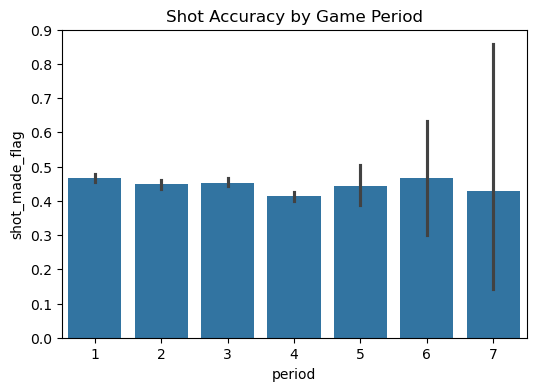

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(x='period', y='shot_made_flag', data=nba)
plt.title("Shot Accuracy by Game Period")
plt.show()

- Shooting accuracy fluctuates across periods.
- Small variations may reflect differences in game intensity and player fatigue, but no extreme pattern is observed.

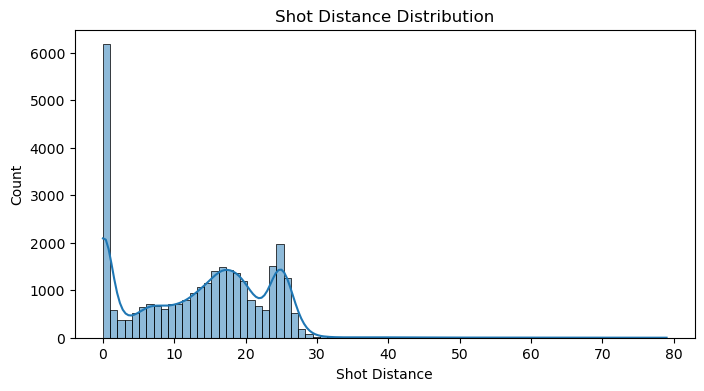

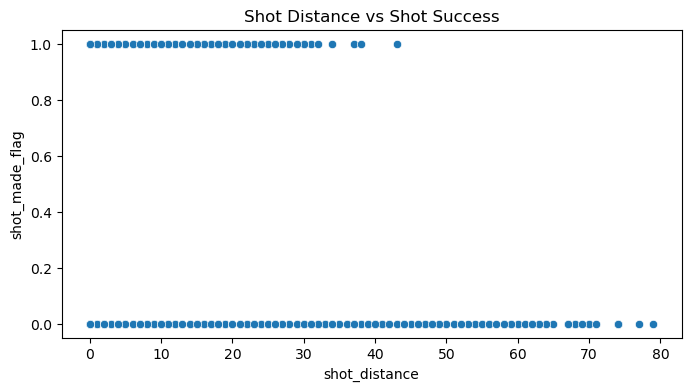

In [27]:
plt.figure(figsize=(8,4))
sns.histplot(nba['shot_distance'], kde=True)
plt.title("Shot Distance Distribution")
plt.xlabel("Shot Distance")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(x='shot_distance', y='shot_made_flag', data=nba)
plt.title("Shot Distance vs Shot Success")
plt.show()

- A clear trend shows that shorter distances correlate with higher probability of making a shot.
- Long-distance shots tend to be less accurate.

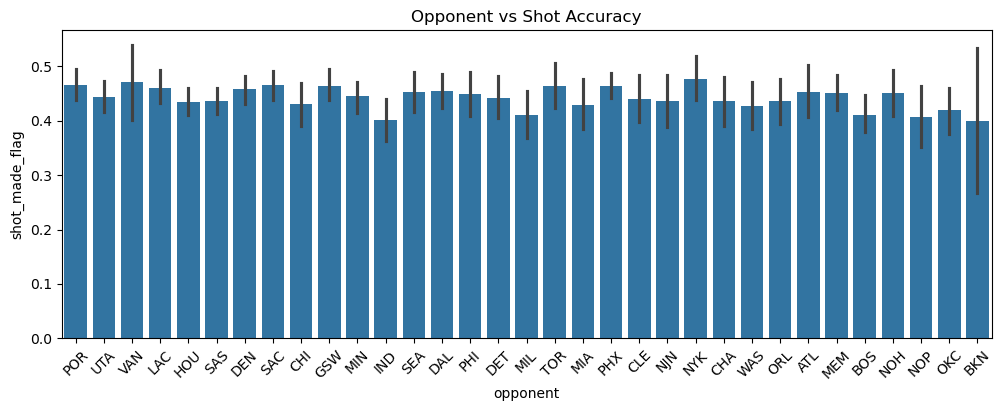

In [28]:
plt.figure(figsize=(12,4))
sns.barplot(x='opponent', y='shot_made_flag', data=nba)
plt.title("Opponent vs Shot Accuracy")
plt.xticks(rotation=45)
plt.show()

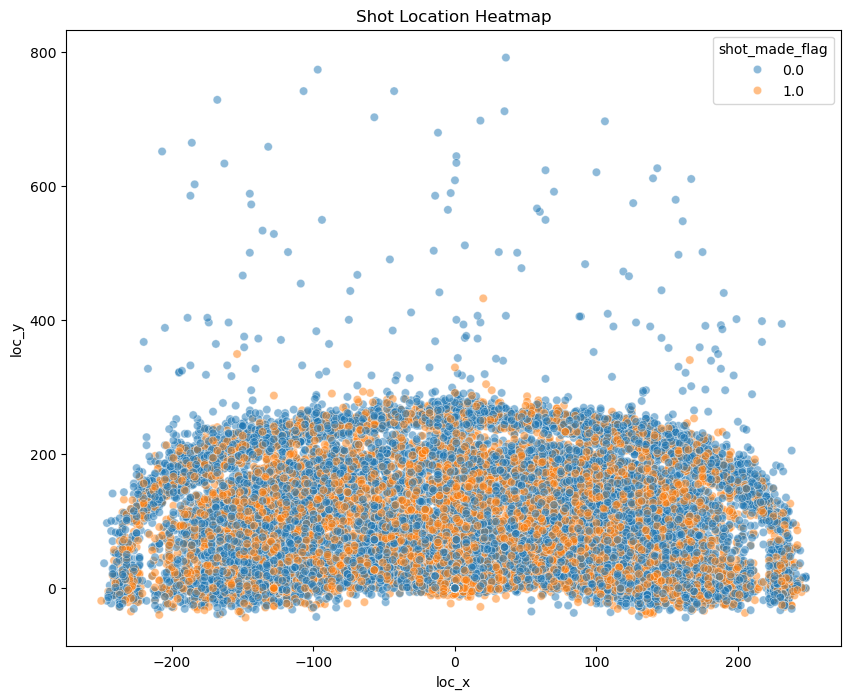

In [29]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=nba, x='loc_x', y='loc_y', hue='shot_made_flag', alpha=0.5)
plt.title("Shot Location Heatmap")
plt.show()

- Successful shots cluster around the basket area.
- Missed shots are more spread out, especially in long-range positions.
- This reflects standard NBA shooting dynamics.

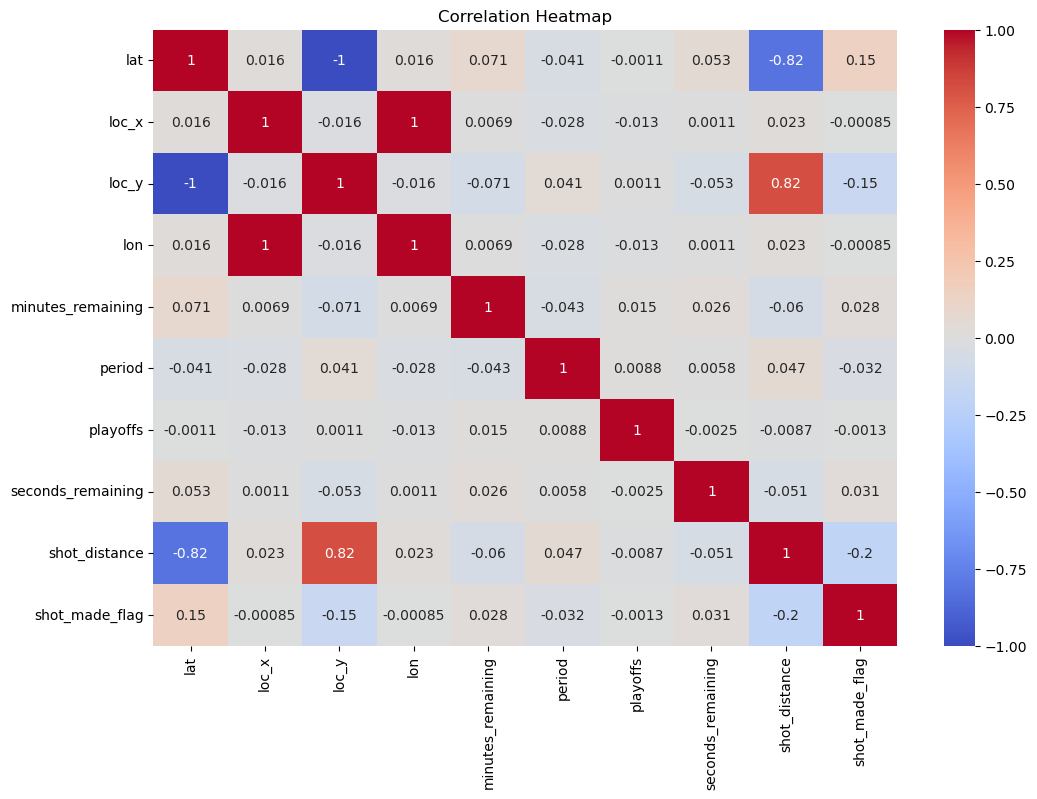

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(nba.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Shot distance has a strong negative correlation with shot success (–0.20), indicating that longer shots are less likely to be made.
lat and loc_y show a strong positive correlation (~0.82), while lat and shot_distance show a strong negative correlation (–0.82), confirming that court position strongly influences shot distance.
- Other features such as minutes_remaining, period, and playoffs have very weak correlations with the target, meaning they have minimal direct impact on predicting shot success.

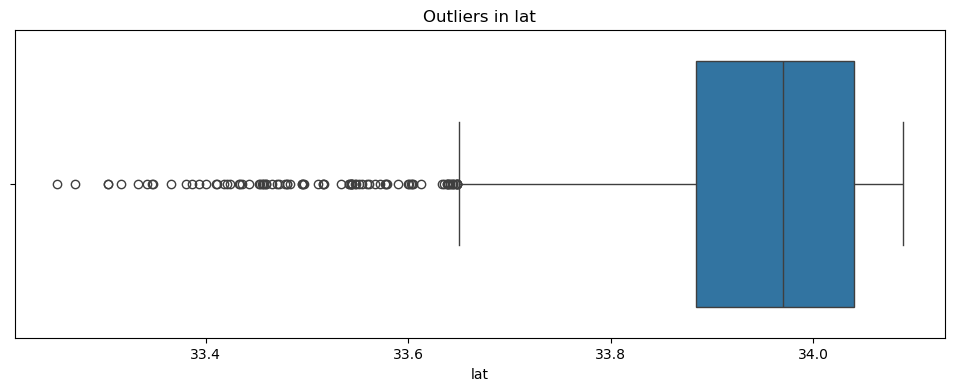

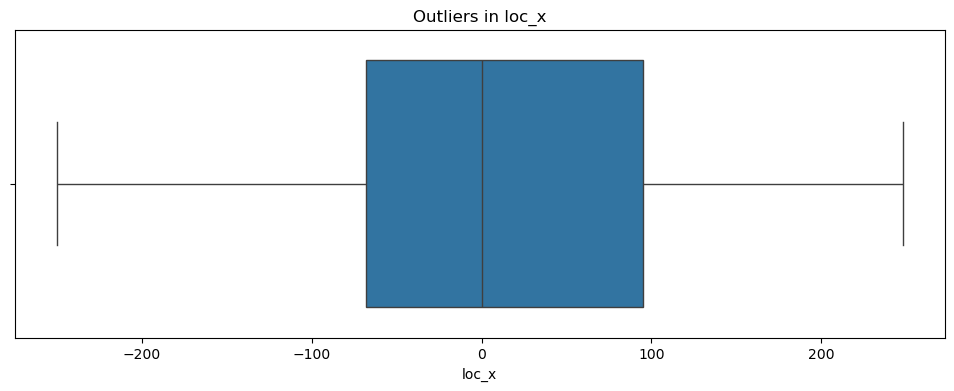

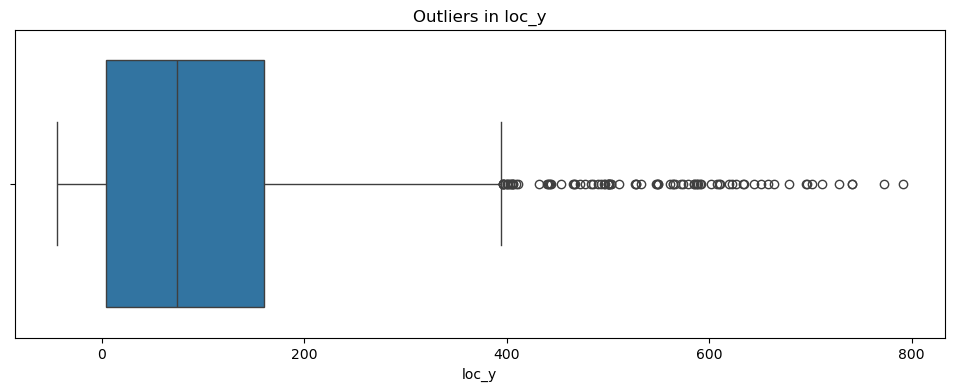

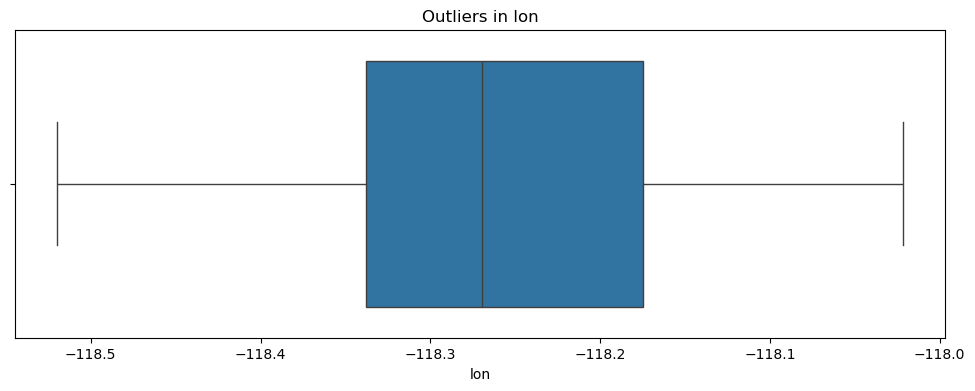

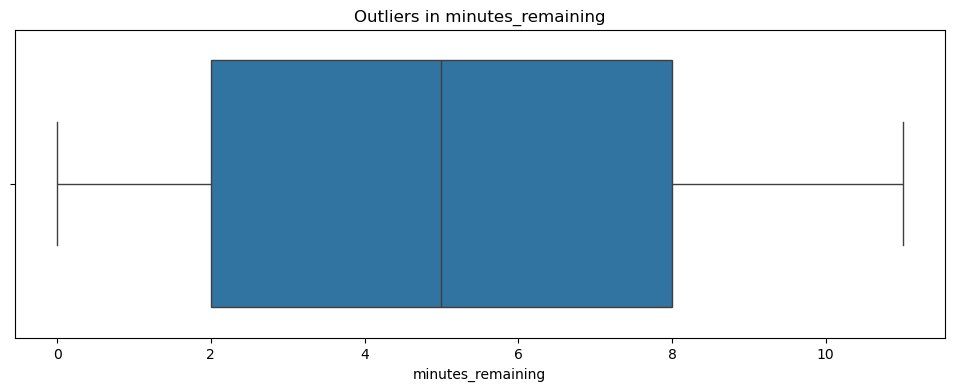

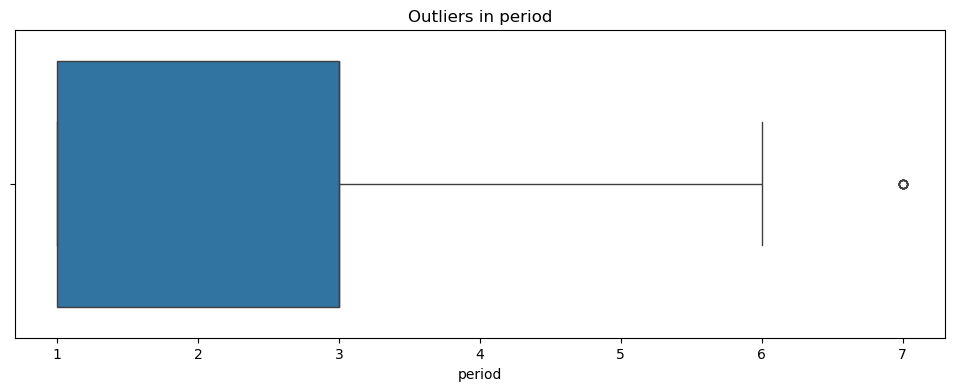

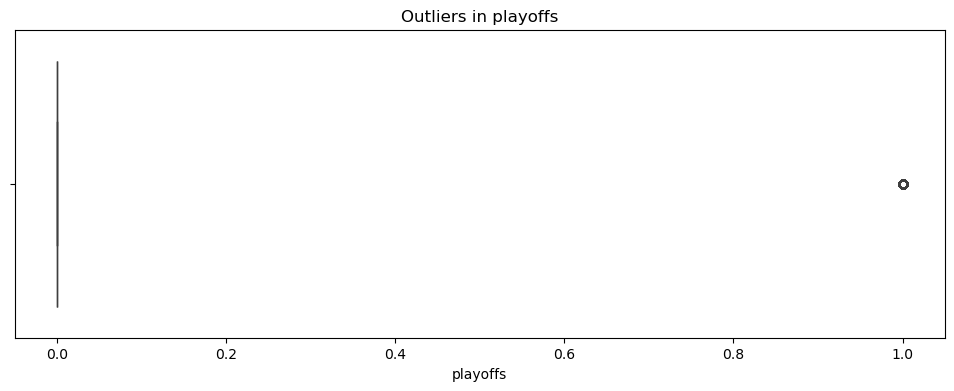

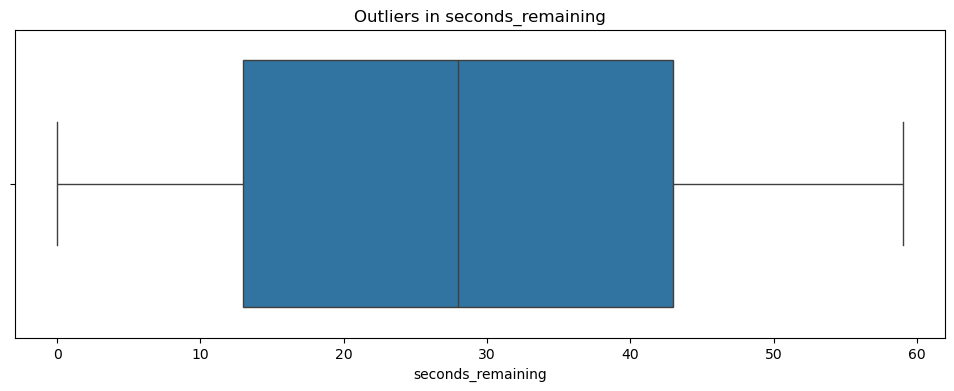

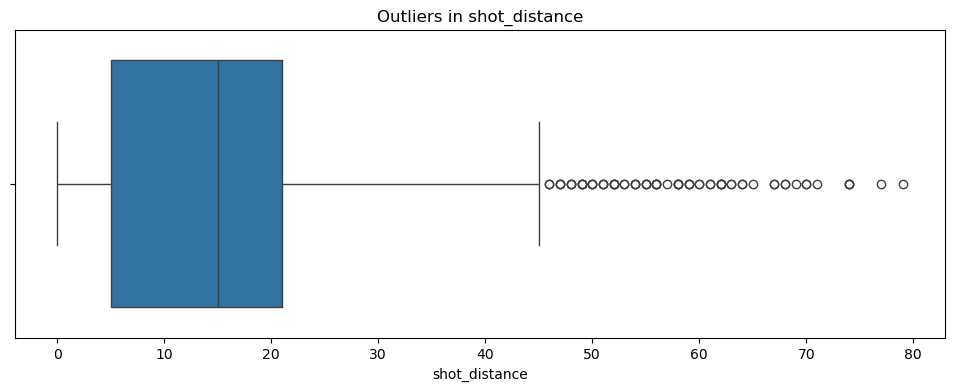

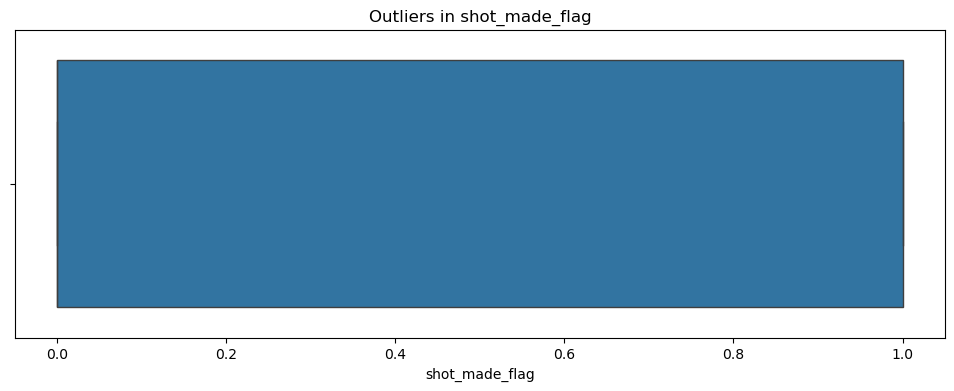

In [31]:
num_cols = nba.drop("shot_made_flag", axis=1)
num_cols = nba.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(12,4))
    sns.boxplot(x=nba[col])
    plt.title(f"Outliers in {col}")
    plt.show()

- Several features show outliers, they represent valid game situations (e.g., long-distance shots or extreme court positions). These values are important for modeling real basketball behavior, so no outlier removal is applied.
- Therefore, these outliers are intentionally retained, as removing them would distort the true distribution of on-court behavior and reduce the model’s ability to generalize to real gameplay scenarios.

### 4. Semi-Supervised Model

1. The Target variable contains several null values. Unlike other features, we cannot remove or impute these missing target values, because the model requires a label to learn. Instead of dropping those rows, I used a semi-supervised learning approach to predict these missing target values.

2. In this method, the model is first trained on the rows with known labels, and then it is used to generate pseudo-labels for the rows where the target is null. These pseudo-labeled rows are added back to the dataset to retrain the final model.

In [32]:
labeled_nba = nba[nba['shot_made_flag'].notnull()]
unlabeled_nba = nba[nba['shot_made_flag'].isnull()]
print(labeled_nba.shape)
print(unlabeled_nba.shape)

(25697, 20)
(5000, 20)


In [33]:
labeled_X = pd.get_dummies(labeled_nba.drop('shot_made_flag', axis=1), drop_first=True)

In [34]:
labeled_X_scaled = scaler.fit_transform(labeled_X)

In [35]:
unlabeled_X = pd.get_dummies(unlabeled_nba.drop('shot_made_flag', axis=1), drop_first=True)
unlabeled_X = unlabeled_X.reindex(columns=labeled_X.columns, fill_value=0)
unlabeled_X_scaled = scaler.transform(unlabeled_X)

In [36]:
X_labeled = labeled_nba.drop('shot_made_flag', axis=1)
y_labeled = labeled_nba['shot_made_flag']

In [37]:
X_unlabeled = unlabeled_nba.drop('shot_made_flag', axis=1)

In [38]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.ensemble import RandomForestClassifier

base_model = RandomForestClassifier(n_estimators=200, random_state=42)

self_training_model = SelfTrainingClassifier(
    base_estimator=base_model,
    threshold=0.7,
    verbose=True
)

self_training_model.fit(labeled_X_scaled, y_labeled)


C:\Users\User\anaconda3a\Lib\site-packages\sklearn\semi_supervised\_self_training.py:210: FutureWarning: `base_estimator` has been deprecated in 1.6 and will be removed in 1.8. Please use `estimator` instead.
  warn(
C:\Users\User\anaconda3a\Lib\site-packages\sklearn\semi_supervised\_self_training.py:288: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)


SelfTrainingClassifier(base_estimator=RandomForestClassifier(n_estimators=200,
                                                             random_state=42),
                       threshold=0.7, verbose=True)

In [39]:
pseudo_labels = self_training_model.predict(unlabeled_X_scaled)

In [40]:
nba.loc[nba['shot_made_flag'].isnull(), 'shot_made_flag'] = pseudo_labels

In [41]:
final_nba = nba.copy()

In [42]:
final_nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   lat                 30697 non-null  float64
 3   loc_x               30697 non-null  int64  
 4   loc_y               30697 non-null  int64  
 5   lon                 30697 non-null  float64
 6   minutes_remaining   30697 non-null  int64  
 7   period              30697 non-null  int64  
 8   playoffs            30697 non-null  int64  
 9   season              30697 non-null  object 
 10  seconds_remaining   30697 non-null  int64  
 11  shot_distance       30697 non-null  int64  
 12  shot_made_flag      30697 non-null  float64
 13  shot_type           30697 non-null  object 
 14  shot_zone_area      30697 non-null  object 
 15  shot_zone_basic     30697 non-null  object 
 16  shot

In [43]:
final_nba["shot_made_flag"].value_counts()

shot_made_flag
0.0    17650
1.0    13047
Name: count, dtype: int64

- Here, the original target variable’s null values have been replaced using the Semi-Supervised Model.

In [44]:
x = final_nba.drop("shot_made_flag", axis=1)
y = final_nba["shot_made_flag"]

In [45]:
final_nba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   lat                 30697 non-null  float64
 3   loc_x               30697 non-null  int64  
 4   loc_y               30697 non-null  int64  
 5   lon                 30697 non-null  float64
 6   minutes_remaining   30697 non-null  int64  
 7   period              30697 non-null  int64  
 8   playoffs            30697 non-null  int64  
 9   season              30697 non-null  object 
 10  seconds_remaining   30697 non-null  int64  
 11  shot_distance       30697 non-null  int64  
 12  shot_made_flag      30697 non-null  float64
 13  shot_type           30697 non-null  object 
 14  shot_zone_area      30697 non-null  object 
 15  shot_zone_basic     30697 non-null  object 
 16  shot

#### 5. Scaling and Feature Engineering

In [46]:
x = pd.get_dummies(x, drop_first=True)

In [47]:
x_scaling = scaler.fit_transform(x)
x_scaling

array([[ 0.21765064,  1.45192025, -0.21765064, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [ 1.03779025, -1.49025018, -1.03779025, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [-0.49997152, -0.9817269 ,  0.49997152, ..., -0.22586537,
        -0.08988077, -0.14119328],
       ...,
       [-0.85308718, -1.2813924 ,  0.85308718, ..., -0.22586537,
        -0.08988077, -0.14119328],
       [-2.0035608 ,  0.21693513,  2.0035608 , ..., -0.22586537,
        -0.08988077, -0.14119328],
       [ 0.21765064, -0.05548806, -0.21765064, ..., -0.22586537,
        -0.08988077, -0.14119328]])

In [48]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_scaling,y,test_size = 0.3, random_state = 42)
print("x_train1",x_train1.shape)
print("x_test1",x_test1.shape)
print("y_train1", y_train1.shape)
print("y_test1",y_test1.shape)

x_train1 (21487, 1768)
x_test1 (9210, 1768)
y_train1 (21487,)
y_test1 (9210,)


### 6. Model Development
Testing with Multiple Models for Better Prediction

#### Logistic Regression

In [49]:
lr=LogisticRegression()
lr.fit(x_train1,y_train1)

LogisticRegression()

In [51]:
y_pr = lr.predict(x_test1)
accuracy_score(y_test1,y_pr)

0.6967426710097719

In [52]:
y_pre = lr.predict(x_train1)
accuracy_score(y_train1,y_pre)

0.7361660538930516

In [53]:
from sklearn.metrics import classification_report
lr_report_test = print(classification_report(y_test1, y_pr))
lr_report_train = print(classification_report(y_train1, y_pre))

              precision    recall  f1-score   support

         0.0       0.70      0.82      0.76      5268
         1.0       0.69      0.53      0.60      3942

    accuracy                           0.70      9210
   macro avg       0.70      0.68      0.68      9210
weighted avg       0.70      0.70      0.69      9210

              precision    recall  f1-score   support

         0.0       0.73      0.86      0.79     12382
         1.0       0.75      0.57      0.65      9105

    accuracy                           0.74     21487
   macro avg       0.74      0.71      0.72     21487
weighted avg       0.74      0.74      0.73     21487



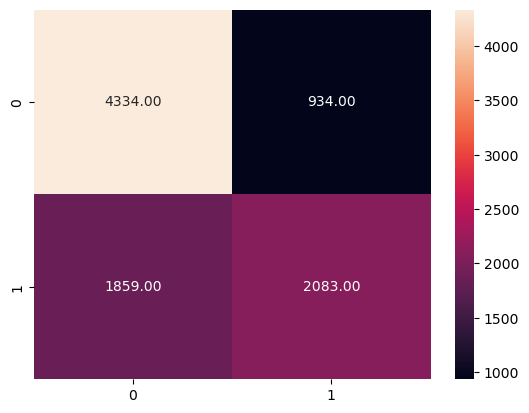

In [56]:
from sklearn.metrics import confusion_matrix
cm=sns.heatmap(confusion_matrix(y_test1, y_pr),annot = True,fmt='.2f');

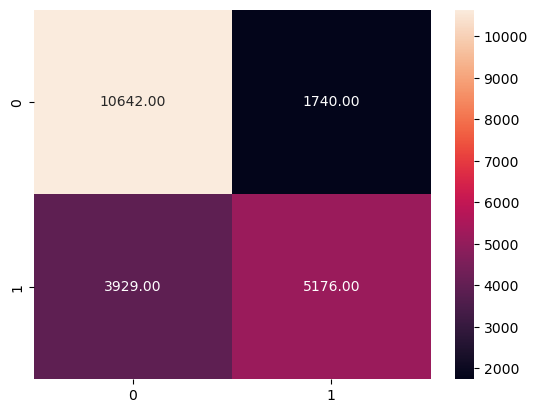

In [57]:
cm=sns.heatmap(confusion_matrix(y_train1,y_pre),annot = True,fmt='.2f');

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)

#### Random Forest Classifier

#### Using GridSearchCV to understand better parameters

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],   
    'bootstrap': [True, False]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,          
    n_jobs=-1,         
    verbose=2,
    scoring='accuracy'       
)

grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)


Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Params: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Score: 0.723553736519424


In [60]:
rfc = RandomForestClassifier(random_state=42, bootstrap= True, max_depth= None, max_features= 'sqrt',
min_samples_leaf= 1, min_samples_split= 5, n_estimators= 300)

rfc.fit(x_train,y_train)
y_predict = rfc.predict(x_test)
y_predic = rfc.predict(x_train)

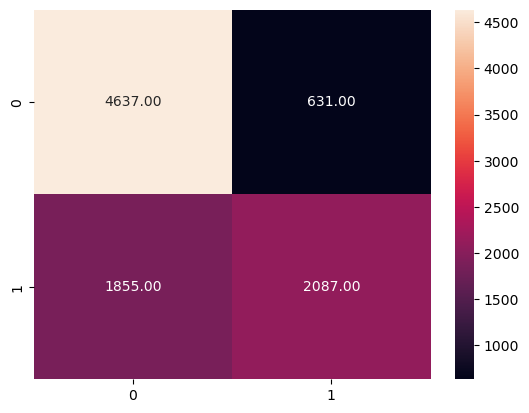

In [61]:
cm=sns.heatmap(confusion_matrix(y_test, y_predict),annot = True,fmt='.2f');

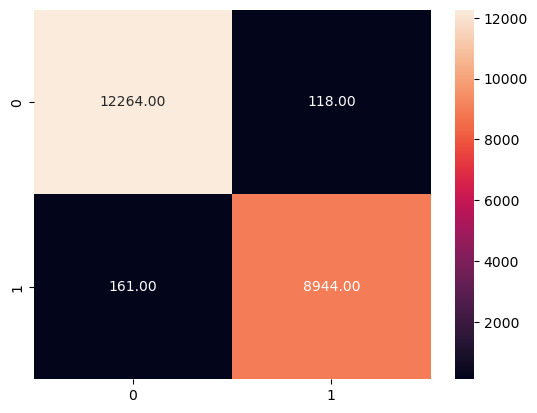

In [62]:
cm=sns.heatmap(confusion_matrix(y_train, y_predic),annot = True,fmt='.2f');

#### XGB Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb = XGBClassifier(
    objective='binary:logistic',
    
    eval_metric='logloss',
    use_label_encoder=False
)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,        
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


In [35]:
from xgboost import XGBClassifier
best_model = XGBClassifier(
    colsample_bytree=0.8121770240668966,
    gamma=1.47816842918857,
    learning_rate=0.041648277949081186,
    max_depth=10,
    min_child_weight=8,
    n_estimators=385,
    subsample=0.9416401294594341,
    scale_pos_weight=17650/13047,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_predc = best_model.predict(x_train)

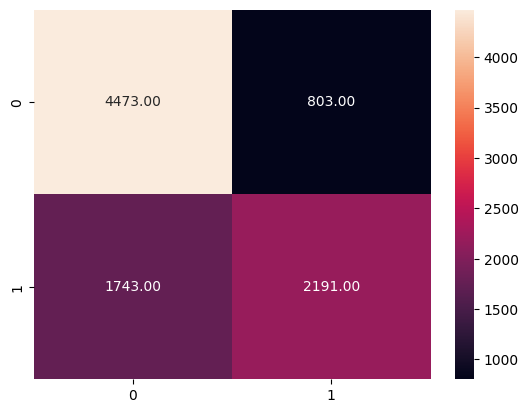

In [50]:
cm=sns.heatmap(confusion_matrix(y_test, y_pred),annot = True,fmt='.2f');

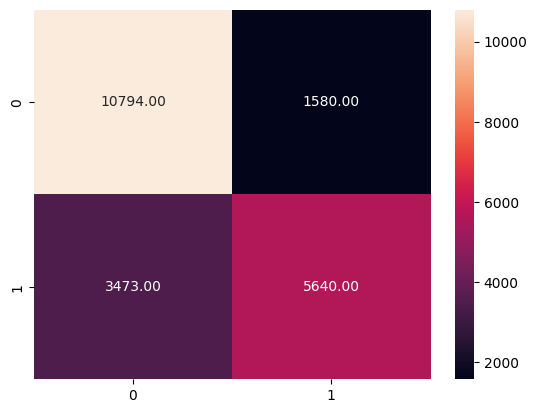

In [49]:
cm=sns.heatmap(confusion_matrix(y_train, y_predc),annot = True,fmt='.2f');

#### LightGBM Classifier

In [37]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

param_dist_lgb = {
    'n_estimators': randint(300, 1500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.15),
    'num_leaves': randint(20, 150),
    'min_child_samples': randint(10, 80),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    lgb,
    param_distributions=param_dist_lgb,
    n_iter=50,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

lgb_search.fit(x_train, y_train)

print("Best parameters for LightGBM:")
print(lgb_search.best_params_)

lgb_best = lgb_search.best_estimator_

lgb_preds = lgb_best.predict(x_test)
lgb_pred = lgb_best.predict(x_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9113, number of negative: 12374
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050343 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3334
[LightGBM] [Info] Number of data points in the train set: 21487, number of used features: 1102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.424117 -> initscore=-0.305896
[LightGBM] [Info] Start training from score -0.305896
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

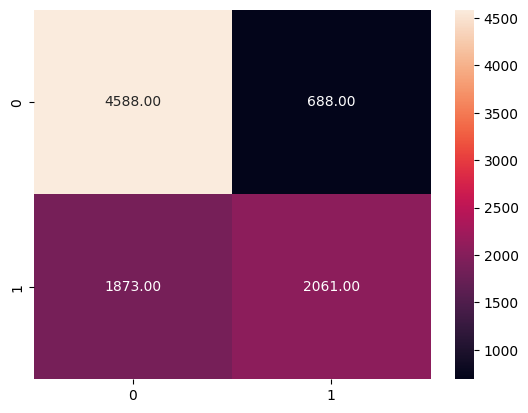

In [51]:
cm=sns.heatmap(confusion_matrix(y_test, lgb_preds),annot = True,fmt='.2f');

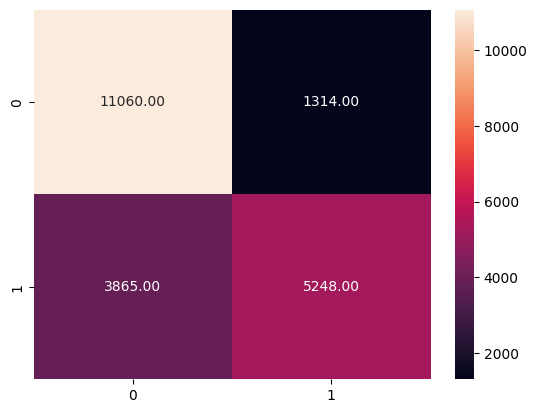

In [52]:
cm=sns.heatmap(confusion_matrix(y_train, lgb_pred),annot = True,fmt='.2f');

### Consolidated Evaluation Report

In [6]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rfc,
    "XGBoost": best_model,
    "LightGBM": lgb_best
}

def get_predictions(model_name, model):

    if model_name == "Logistic Regression":
        train_pred = model.predict(x_train1)
        test_pred = model.predict(x_test1)
    else:
        train_pred = model.predict(x_train)
        test_pred = model.predict(x_test)

    return train_pred, test_pred


def evaluate_model(model_name, model):

    train_pred, test_pred = get_predictions(model_name, model)

    return {
        "Model": model_name,

        "Train Accuracy": accuracy_score(y_train if model_name!="Logistic Regression"else y_test1, test_pred),
        "Test Precision(1)": precision_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred, pos_label=1),
        "Test Recall(1)": recall_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred, pos_label=1),
        "Test F1(1)": f1_score(y_test if model_name!="Logistic Regression" else y_test1, test_pred, pos_label=1),
    }


rows = [evaluate_model(name, model) for name, model in models.items()]
comparison_df = pd.DataFrame(rows).set_index("Model")

comparison_df.style.format("{:.4f}")

NameError: name 'lr' is not defined

### 7. Conlusion

1. Our dataset contains null values in the target variable.Training a model with missing labels will lead to unreliable performance. Therefore, we used a Semi-Supervised Model to generate pseudo-labels for those rows. However, to improve the model’s true reliability, we still need actual labeled samples for the target variable.

2. Since we do not have exact ground-truth values for a large portion of the target variable, tuning the threshold is not suitable for this model.
Threshold tuning relies on accurate labels, which are not available for the pseudo-labeled rows.

3. Among all the models tested, the XGBClassifier performed the best. Because the dataset contains missing target values, accuracy is not the correct metric to evaluate the model. Instead, Precision, Recall, and F1 Score give a more meaningful understanding of performance. Since XGBoost shows a good balance across these metrics, it can be considered the most suitable model for this dataset.